# Challenge 5 — Clustering Education Systems
## Group 4 · NCES CCD SY 2022-23
### Universidad Distrital Francisco José de Caldas — Machine Learning

## 0. Install & Setup

In [2]:
import subprocess
subprocess.run(["pip", "install", "numpy", "pandas", "matplotlib",
                "seaborn", "scikit-learn", "scipy"], check=True)
print("Dependencies installed.")

Dependencies installed.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [3]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, adjusted_rand_score)
from scipy.cluster.hierarchy import dendrogram, linkage

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("/workspaces/challenge-5_4/data")
FIG_DIR  = Path("/workspaces/challenge-5_4/figures")
FIG_DIR.mkdir(exist_ok=True)

F_DIR   = "ccd_sch_029_2223_w_1a_083023.csv"
F_LUNCH = "ccd_sch_033_2223_l_1a_083023.csv"
F_MEM   = "ccd_sch_052_2223_l_1a_083023.csv"
F_STAFF = "ccd_sch_059_2223_l_1a_083023.csv"
F_CHAR  = "ccd_sch_129_2223_w_1a_083023.csv"

print("Setup complete.")

Setup complete.


## 1. Data Loading & Merging

In [4]:
# 1.1 Directory
dir_cols = ['NCESSCH','SCH_NAME','LEA_NAME','STATENAME','ST',
            'SCH_TYPE','SCH_TYPE_TEXT','CHARTER_TEXT','LEVEL',
            'SY_STATUS','GSLO','GSHI']
df_dir = pd.read_csv(DATA_DIR/F_DIR, usecols=dir_cols, low_memory=False)
df_dir = df_dir[df_dir['SY_STATUS']==1].copy()
print(f"Directory: {df_dir.shape[0]:,} open schools")

Directory: 99,528 open schools


In [5]:
# 1.2 School Characteristics
df_char = pd.read_csv(DATA_DIR/F_CHAR,
                      usecols=['NCESSCH','VIRTUAL','NSLP_STATUS','SHARED_TIME'])
print(f"Characteristics: {df_char.shape[0]:,} records")

Characteristics: 100,571 records


In [6]:
# 1.3 Staff
df_staff_raw = pd.read_csv(DATA_DIR/F_STAFF,
                           usecols=['NCESSCH','TEACHERS','TOTAL_INDICATOR'])
df_staff = (df_staff_raw[df_staff_raw['TOTAL_INDICATOR']=='Education Unit Total']
            [['NCESSCH','TEACHERS']].copy())
df_staff['TEACHERS'] = pd.to_numeric(df_staff['TEACHERS'], errors='coerce')
print(f"Staff: {df_staff.shape[0]:,} records")

Staff: 100,571 records


In [7]:
# 1.4 Lunch Eligibility
lunch_cols = ['NCESSCH','LUNCH_PROGRAM','STUDENT_COUNT','DATA_GROUP','TOTAL_INDICATOR']
df_lunch_raw = pd.read_csv(DATA_DIR/F_LUNCH, usecols=lunch_cols)
df_lunch_raw['STUDENT_COUNT'] = pd.to_numeric(df_lunch_raw['STUDENT_COUNT'], errors='coerce')
df_lunch = (df_lunch_raw[
    (df_lunch_raw['DATA_GROUP']=='Free and Reduced-price Lunch Table') &
    (df_lunch_raw['TOTAL_INDICATOR']=='Education Unit Total') &
    (df_lunch_raw['LUNCH_PROGRAM'].isin(['Free lunch qualified',
                                         'Reduced-price lunch qualified']))
].groupby('NCESSCH')['STUDENT_COUNT'].sum().reset_index()
 .rename(columns={'STUDENT_COUNT':'FRPL_COUNT'}))
print(f"Lunch: {df_lunch.shape[0]:,} schools")

Lunch: 0 schools


In [8]:
# 1.5 Membership — race/ethnicity totals per school
# Data is by grade x sex x race — we sum all grades and both sexes
race_map = {
    'White': 'n_white',
    'Hispanic/Latino': 'n_hispanic',
    'Black or African American': 'n_black',
    'Asian': 'n_asian',
    'American Indian or Alaska Native': 'n_aian',
    'Two or more races': 'n_multirace',
    'Native Hawaiian or Other Pacific Islander': 'n_nhopi',
}
mem_cols = ['NCESSCH','RACE_ETHNICITY','SEX','STUDENT_COUNT','GRADE',
            'TOTAL_INDICATOR','DMS_FLAG']
chunk_list = []
for chunk in pd.read_csv(DATA_DIR/F_MEM, usecols=mem_cols, chunksize=500_000):
    chunk['STUDENT_COUNT'] = pd.to_numeric(chunk['STUDENT_COUNT'], errors='coerce')
    chunk_list.append(chunk[
        (chunk['DMS_FLAG'] == 'Reported') &
        (chunk['RACE_ETHNICITY'].isin(race_map.keys())) &
        (chunk['SEX'].isin(['Male','Female']))
    ])
df_mem_all = pd.concat(chunk_list, ignore_index=True)

df_race_sum = (df_mem_all
               .groupby(['NCESSCH','RACE_ETHNICITY'])['STUDENT_COUNT']
               .sum().reset_index())
df_race_sum['RACE_ETHNICITY'] = df_race_sum['RACE_ETHNICITY'].map(race_map)

df_race_wide = (df_race_sum
                .groupby(['NCESSCH','RACE_ETHNICITY'])['STUDENT_COUNT']
                .sum().unstack(fill_value=0).reset_index())
df_race_wide.columns.name = None

race_cols = [c for c in df_race_wide.columns if c != 'NCESSCH']
df_race_wide['TOTAL_ENROLLMENT'] = df_race_wide[race_cols].sum(axis=1)
df_enroll = df_race_wide[['NCESSCH','TOTAL_ENROLLMENT']].copy()

print(f"Race wide: {df_race_wide.shape}, columns: {df_race_wide.columns.tolist()}")

Race wide: (98931, 9), columns: ['NCESSCH', 'n_aian', 'n_asian', 'n_black', 'n_hispanic', 'n_multirace', 'n_nhopi', 'n_white', 'TOTAL_ENROLLMENT']


In [9]:
# 1.6 Master merge
df = (df_dir
      .merge(df_char,     on='NCESSCH', how='left')
      .merge(df_staff,    on='NCESSCH', how='left')
      .merge(df_lunch,    on='NCESSCH', how='left')
      .merge(df_enroll,   on='NCESSCH', how='left')
      .merge(df_race_wide, on='NCESSCH', how='left'))
print(f"Master: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(df.columns.tolist())

Master: 99,528 rows x 26 cols
['STATENAME', 'ST', 'SCH_NAME', 'LEA_NAME', 'NCESSCH', 'SY_STATUS', 'SCH_TYPE_TEXT', 'SCH_TYPE', 'CHARTER_TEXT', 'GSLO', 'GSHI', 'LEVEL', 'SHARED_TIME', 'NSLP_STATUS', 'VIRTUAL', 'TEACHERS', 'FRPL_COUNT', 'TOTAL_ENROLLMENT_x', 'n_aian', 'n_asian', 'n_black', 'n_hispanic', 'n_multirace', 'n_nhopi', 'n_white', 'TOTAL_ENROLLMENT_y']


## 2. EDA

In [10]:
print("School Level:"); print(df['LEVEL'].value_counts())
print("\nCharter:"); print(df['CHARTER_TEXT'].value_counts())
print("\nMissing (%):"); print((df.isnull().mean()*100).round(2).sort_values(ascending=False).head(10))

School Level:
LEVEL
Elementary         52789
High               23368
Middle             16252
Other               4362
Prekindergarten     1521
Not reported         405
Secondary            400
Not applicable       276
Ungraded             134
Adult Education       21
Name: count, dtype: int64

Charter:
CHARTER_TEXT
No                88179
Yes                7702
Not applicable     3647
Name: count, dtype: int64

Missing (%):
FRPL_COUNT            100.00
TEACHERS                2.93
n_aian                  1.61
n_asian                 1.61
n_black                 1.61
n_hispanic              1.61
n_multirace             1.61
TOTAL_ENROLLMENT_x      1.61
n_nhopi                 1.61
n_white                 1.61
dtype: float64


In [11]:
print(df.columns.tolist())

['STATENAME', 'ST', 'SCH_NAME', 'LEA_NAME', 'NCESSCH', 'SY_STATUS', 'SCH_TYPE_TEXT', 'SCH_TYPE', 'CHARTER_TEXT', 'GSLO', 'GSHI', 'LEVEL', 'SHARED_TIME', 'NSLP_STATUS', 'VIRTUAL', 'TEACHERS', 'FRPL_COUNT', 'TOTAL_ENROLLMENT_x', 'n_aian', 'n_asian', 'n_black', 'n_hispanic', 'n_multirace', 'n_nhopi', 'n_white', 'TOTAL_ENROLLMENT_y']


In [12]:
# Renombrar TOTAL_ENROLLMENT_x a TOTAL_ENROLLMENT y eliminar la duplicada
df = df.rename(columns={'TOTAL_ENROLLMENT_x': 'TOTAL_ENROLLMENT'})
df = df.drop(columns=['TOTAL_ENROLLMENT_y'])
print(df.columns.tolist())

['STATENAME', 'ST', 'SCH_NAME', 'LEA_NAME', 'NCESSCH', 'SY_STATUS', 'SCH_TYPE_TEXT', 'SCH_TYPE', 'CHARTER_TEXT', 'GSLO', 'GSHI', 'LEVEL', 'SHARED_TIME', 'NSLP_STATUS', 'VIRTUAL', 'TEACHERS', 'FRPL_COUNT', 'TOTAL_ENROLLMENT', 'n_aian', 'n_asian', 'n_black', 'n_hispanic', 'n_multirace', 'n_nhopi', 'n_white']


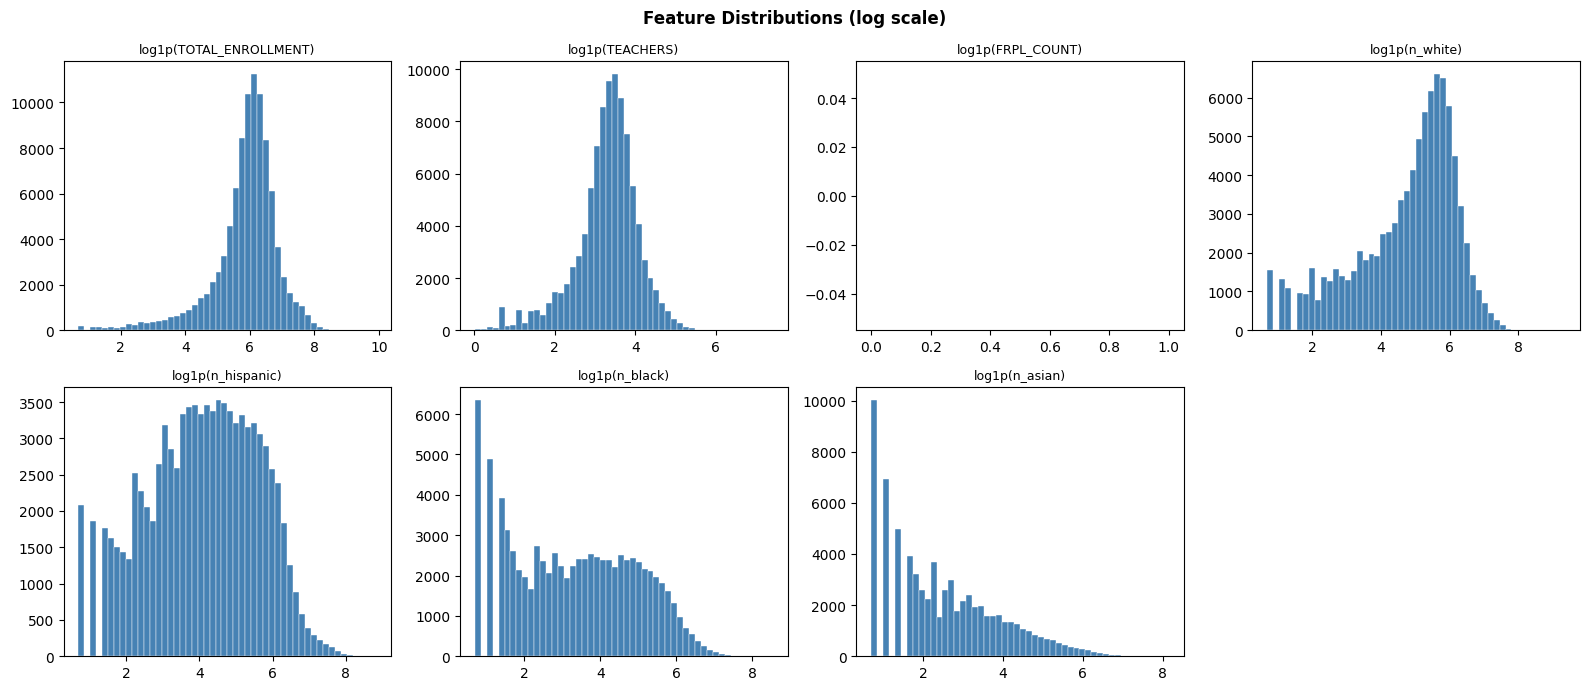

Saved eda_distributions.png


In [13]:
num_cols = ['TOTAL_ENROLLMENT','TEACHERS','FRPL_COUNT',
            'n_white','n_hispanic','n_black','n_asian']
fig, axes = plt.subplots(2, 4, figsize=(16,7))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    data = df[col].dropna(); data = data[data>0]
    axes[i].hist(np.log1p(data), bins=50, color='steelblue', edgecolor='white', lw=0.3)
    axes[i].set_title(f'log1p({col})', fontsize=9)
axes[-1].axis('off')
plt.suptitle('Feature Distributions (log scale)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR/'eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved eda_distributions.png")

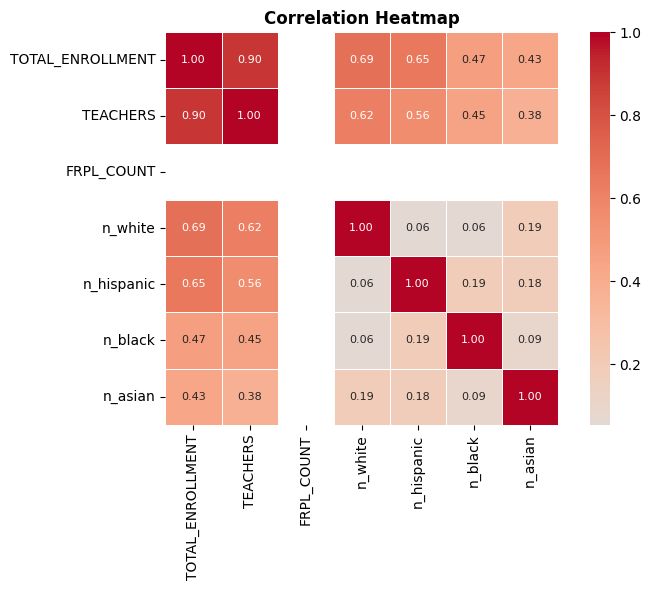

In [14]:
corr = df[['TOTAL_ENROLLMENT','TEACHERS','FRPL_COUNT',
           'n_white','n_hispanic','n_black','n_asian']].corr()
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, annot_kws={'size':8})
ax.set_title('Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR/'eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Preprocessing

In [15]:
LEVEL_MAP = {'Elementary':0,'Prekindergarten':0,'Middle':1,
             'High':2,'Secondary':2,'Other':3,'Not reported':3}
FEATURE_COLS = ['log_enrollment','pct_free_reduced_lunch',
                'pct_white','pct_hispanic','pct_black','pct_asian','pct_multirace',
                'student_teacher_ratio','is_charter','is_virtual','school_level_enc']

df_feat = df.copy()
total = df_feat['TOTAL_ENROLLMENT'].replace(0, np.nan)
df_feat['pct_free_reduced_lunch'] = df_feat['FRPL_COUNT'] / total
df_feat['pct_white']     = df_feat['n_white']     / total
df_feat['pct_hispanic']  = df_feat['n_hispanic']  / total
df_feat['pct_black']     = df_feat['n_black']     / total
df_feat['pct_asian']     = df_feat['n_asian']     / total
df_feat['pct_multirace'] = df_feat['n_multirace'] / total
df_feat['student_teacher_ratio'] = (df_feat['TOTAL_ENROLLMENT'] /
    df_feat['TEACHERS'].replace(0,np.nan)).clip(upper=200)
df_feat['is_charter']       = (df_feat['CHARTER_TEXT']=='Yes').astype(int)
df_feat['is_virtual']       = df_feat['VIRTUAL'].isin(['FULLVIRTUAL','SUPPVIRTUAL']).astype(int)
df_feat['school_level_enc'] = df_feat['LEVEL'].map(LEVEL_MAP).fillna(3)
df_feat['log_enrollment']   = np.log1p(df_feat['TOTAL_ENROLLMENT'])

df_model = df_feat[['NCESSCH','SCH_NAME','STATENAME','LEVEL',
                     'CHARTER_TEXT','VIRTUAL'] + FEATURE_COLS].copy()
before = len(df_model)
df_model = df_model.dropna(subset=FEATURE_COLS, thresh=8)
for col in FEATURE_COLS:
    df_model[col].fillna(df_model[col].median(), inplace=True)
print(f"Rows: {before:,} → {len(df_model):,} after cleaning")

Rows: 99,528 → 95,332 after cleaning


In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model[FEATURE_COLS])
print(f"Scaled matrix: {X_scaled.shape}")

Scaled matrix: (95332, 11)


In [17]:
# Verificar y limpiar NaN antes del PCA
print("NaN por columna:")
print(pd.DataFrame(X_scaled, columns=FEATURE_COLS).isnull().sum())

# Reemplazar cualquier NaN restante con 0
X_scaled = np.nan_to_num(X_scaled, nan=0.0)
print("NaN después de limpieza:", np.isnan(X_scaled).sum())

NaN por columna:
log_enrollment                0
pct_free_reduced_lunch    95332
pct_white                     0
pct_hispanic                  0
pct_black                     0
pct_asian                     0
pct_multirace                 0
student_teacher_ratio      2484
is_charter                    0
is_virtual                    0
school_level_enc              0
dtype: int64
NaN después de limpieza: 0


Components for 90% variance: 8


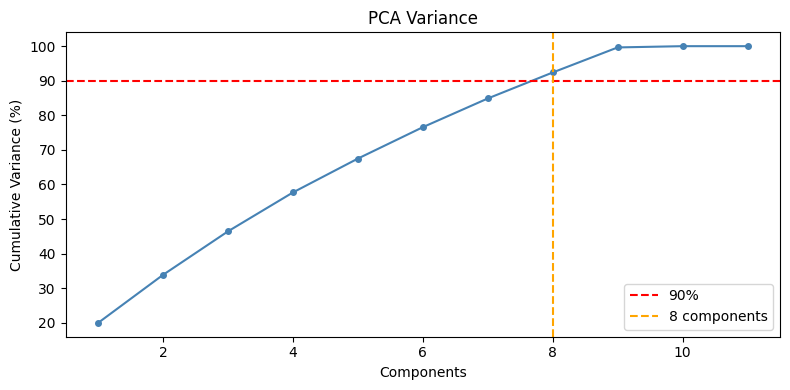

PCA matrix: (95332, 8) | 2D variance: 33.9%


In [18]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components_90 = int(np.searchsorted(cumvar, 0.90)) + 1
print(f"Components for 90% variance: {n_components_90}")

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(range(1,len(cumvar)+1), cumvar*100, 'o-', color='steelblue', ms=4)
ax.axhline(90, color='red', linestyle='--', label='90%')
ax.axvline(n_components_90, color='orange', linestyle='--', label=f'{n_components_90} components')
ax.set(xlabel='Components', ylabel='Cumulative Variance (%)', title='PCA Variance')
ax.legend(); plt.tight_layout()
plt.savefig(FIG_DIR/'pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

pca = PCA(n_components=n_components_90, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca2.fit_transform(X_scaled)
print(f"PCA matrix: {X_pca.shape} | 2D variance: {pca2.explained_variance_ratio_.sum()*100:.1f}%")

In [117]:
RANDOM_STATE = 42
GLOBAL_SAMPLE = 5000

np.random.seed(RANDOM_STATE)

sample_idx = np.random.choice(
    len(X_pca),
    size=GLOBAL_SAMPLE,
    replace=False
)

## 4. K-Means

In [118]:
X_sample = X_pca[sample_idx]

In [121]:
K_RANGE = range(2,13)
inertias, silhouettes = [], []
SEEDS = [42, 7, 123]

for k in K_RANGE:

    sil_runs = []

    for seed in SEEDS:

        km = KMeans(
            n_clusters=k,
            init='k-means++',
            n_init=10,
            random_state=seed
        )

        labels = km.fit_predict(X_pca)

        sil = silhouette_score(
            X_sample,
            labels[sample_idx]
        )

        sil_runs.append(sil)

    silhouettes.append(
        (np.mean(sil_runs), np.std(sil_runs))
    )

    km_f = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=RANDOM_STATE
    ).fit(X_pca)

    inertias.append(km_f.inertia_)

    print(
        f"k={k:2d}  inertia={km_f.inertia_:,.0f}  "
        f"sil={silhouettes[-1][0]:.4f}±{silhouettes[-1][1]:.4f}"
    )

k= 2  inertia=734,512  sil=0.2078±0.0001
k= 3  inertia=653,492  sil=0.2220±0.0106
k= 4  inertia=578,771  sil=0.2363±0.0072
k= 5  inertia=517,492  sil=0.2682±0.0000
k= 6  inertia=455,911  sil=0.2772±0.0000
k= 7  inertia=420,296  sil=0.2670±0.0005
k= 8  inertia=386,573  sil=0.2734±0.0009
k= 9  inertia=357,902  sil=0.2585±0.0003
k=10  inertia=336,917  sil=0.2497±0.0001
k=11  inertia=322,144  sil=0.2384±0.0124
k=12  inertia=310,393  sil=0.2425±0.0111


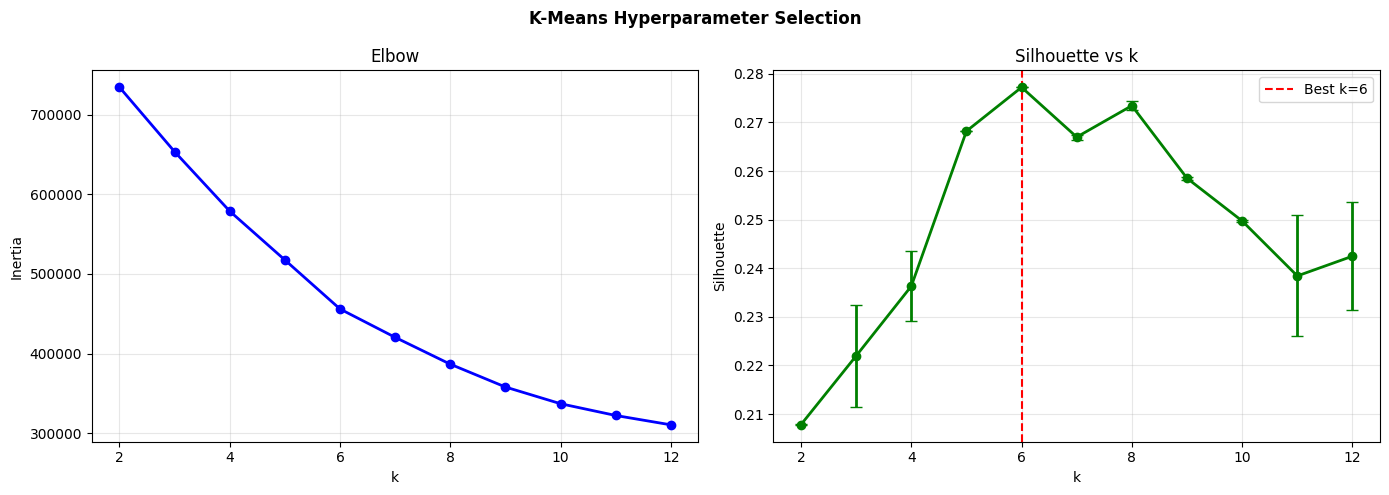

Best k: 6


In [122]:
sil_means = [s[0] for s in silhouettes]
sil_stds  = [s[1] for s in silhouettes]
k_list = list(K_RANGE)
best_k = k_list[int(np.argmax(sil_means))]

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(14,5))
ax1.plot(k_list, inertias, 'bo-', lw=2); ax1.set(xlabel='k', ylabel='Inertia', title='Elbow'); ax1.grid(alpha=0.3)
ax2.errorbar(k_list, sil_means, yerr=sil_stds, fmt='go-', lw=2, capsize=4)
ax2.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
ax2.set(xlabel='k', ylabel='Silhouette', title='Silhouette vs k'); ax2.legend(); ax2.grid(alpha=0.3)
plt.suptitle('K-Means Hyperparameter Selection', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR/'kmeans_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Best k: {best_k}")

In [123]:
K_BEST = best_k
km_best = KMeans(n_clusters=K_BEST, init='k-means++', n_init=20, random_state=RANDOM_STATE)
km_labels = km_best.fit_predict(X_pca)
df_model['km_cluster'] = km_labels

km_sil = silhouette_score(X_pca, km_labels)
km_db  = davies_bouldin_score(X_pca, km_labels)
km_ch  = calinski_harabasz_score(X_pca, km_labels)
print(f"K-Means k={K_BEST} | Silhouette={km_sil:.4f} | DB={km_db:.4f} | CH={km_ch:.1f}")
print(pd.Series(km_labels).value_counts().sort_index())

K-Means k=6 | Silhouette=0.2784 | DB=1.2624 | CH=17671.5
0     5271
1    10134
2    18135
3     7606
4    40400
5    13786
Name: count, dtype: int64


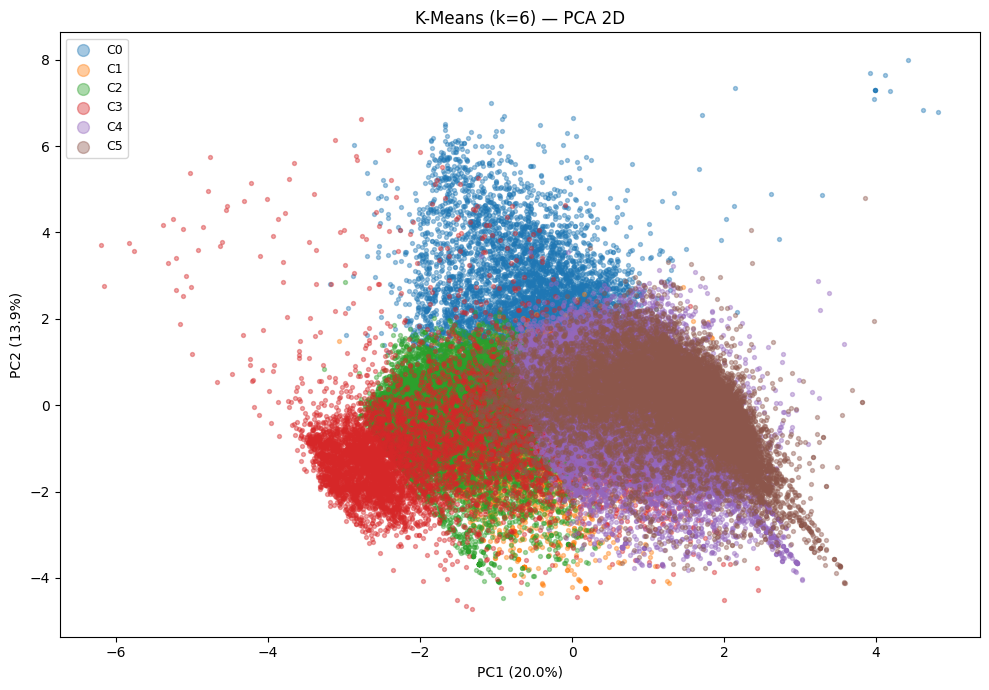

In [124]:
palette = plt.cm.tab10.colors
fig, ax = plt.subplots(figsize=(10,7))
for c in range(K_BEST):
    mask = km_labels==c
    ax.scatter(X_2d[mask,0], X_2d[mask,1], c=[palette[c%10]], label=f'C{c}', alpha=0.4, s=8)
ax.set(xlabel=f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)',
       ylabel=f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)',
       title=f'K-Means (k={K_BEST}) — PCA 2D')
ax.legend(markerscale=3, fontsize=9); plt.tight_layout()
plt.savefig(FIG_DIR/'kmeans_pca2d.png', dpi=150, bbox_inches='tight')
plt.show()

In [125]:
km_profile = df_model.groupby('km_cluster')[FEATURE_COLS].mean().round(3)
km_profile['n_schools'] = df_model.groupby('km_cluster')['NCESSCH'].count()
print("K-Means Cluster Profiles:"); display(km_profile)

K-Means Cluster Profiles:


,log_enrollment,pct_free_reduced_lunch,pct_white,pct_hispanic,pct_black,pct_asian,pct_multirace,student_teacher_ratio,is_charter,is_virtual,school_level_enc,n_schools
km_cluster,,,,,,,,,,,,
0,6.391,NaN,0.281,0.200,0.078,0.330,0.086,17.473,0.028,0.089,0.513,5271
1,5.899,NaN,0.142,0.151,0.636,0.018,0.046,14.358,0.000,0.133,0.716,10134
2,6.079,NaN,0.142,0.708,0.087,0.026,0.025,16.096,0.000,0.044,0.627,18135
3,5.740,NaN,0.294,0.361,0.259,0.025,0.045,22.204,0.981,0.142,1.122,7606
4,5.726,NaN,0.716,0.123,0.054,0.022,0.054,14.663,0.000,0.000,0.701,40400
5,5.830,NaN,0.685,0.127,0.086,0.027,0.056,14.377,0.000,1.000,0.978,13786


## 5. DBSCAN

In [98]:
sample_size = min(5000, len(X_pca))

sample_idx = np.random.choice(
    len(X_pca),
    size=sample_size,
    replace=False
)
X_db = X_pca[sample_idx]

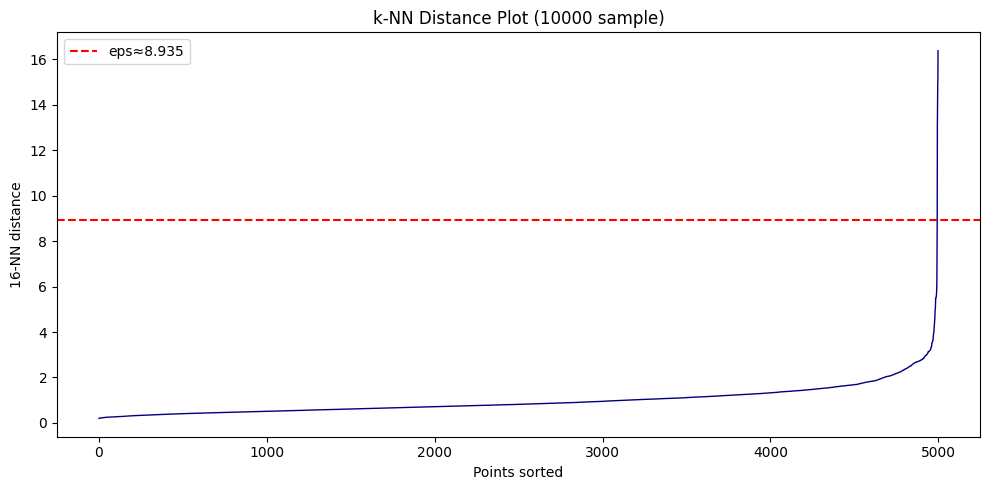

Suggested eps: 8.9347, min_samples: 16


In [99]:
MIN_SAMPLES = max(5, 2 * X_db.shape[1])

from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nn.fit(X_db)

distances, _ = nn.kneighbors(X_db)

knn_dist = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(10,5))

ax.plot(knn_dist, color='navy', lw=1)

elbow_idx = np.argmax(np.gradient(knn_dist))
eps_suggested = knn_dist[elbow_idx]

ax.axhline(
    eps_suggested,
    color='red',
    linestyle='--',
    label=f'eps≈{eps_suggested:.3f}'
)

ax.set(
    xlabel='Points sorted',
    ylabel=f'{MIN_SAMPLES}-NN distance',
    title='k-NN Distance Plot (10000 sample)'
)

ax.legend()
plt.tight_layout()
plt.show()

print(f"Suggested eps: {eps_suggested:.4f}, min_samples: {MIN_SAMPLES}")

In [100]:
eps_values = np.round(
    np.linspace(0.8, 2.0, 13),
    2
)

dbscan_results = []

for eps in eps_values:

    labels = DBSCAN(
        eps=eps,
        min_samples=MIN_SAMPLES
    ).fit_predict(X_db)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_frac = (labels == -1).mean()

    sil = np.nan
    db = np.nan
    ch = np.nan

    if n_clusters >= 2:

        mask = labels != -1

        X_clean = X_db[mask]   # 🔴 FIX: antes X_pca ❌
        y_clean = labels[mask]

        if len(set(y_clean)) >= 2 and len(X_clean) > 10:

            # 🔥 muestreo para evitar freeze
            idx = np.random.choice(
                len(X_clean),
                min(1000, len(X_clean)),
                replace=False
            )

            X_eval = X_clean[idx].astype(np.float32)
            y_eval = y_clean[idx]

            try:
                sil = silhouette_score(X_eval, y_eval)
                db = davies_bouldin_score(X_eval, y_eval)
                ch = calinski_harabasz_score(X_eval, y_eval)
            except Exception as e:
                print("Error métricas:", e)

    dbscan_results.append({
        'eps': eps,
        'n_clusters': n_clusters,
        'noise_frac': round(noise_frac, 4),
        'silhouette': np.round(sil, 4) if not np.isnan(sil) else np.nan,
        'davies_bouldin': np.round(db, 4) if not np.isnan(db) else np.nan,
        'calinski_harabasz': np.round(ch, 1) if not np.isnan(ch) else np.nan
    })

    print(
        f"eps={eps:.4f} clusters={n_clusters} noise={noise_frac:.1%}"
        + (f" sil={sil:.4f}" if not np.isnan(sil) else "")
    )

df_dbscan_sweep = pd.DataFrame(dbscan_results)

eps=0.8000 clusters=10 noise=36.2% sil=0.0288
eps=0.9000 clusters=9 noise=29.5% sil=0.0704
eps=1.0000 clusters=6 noise=24.9% sil=0.1535
eps=1.1000 clusters=5 noise=19.0% sil=0.2425
eps=1.2000 clusters=5 noise=15.4% sil=0.2339
eps=1.3000 clusters=5 noise=11.4% sil=0.2315
eps=1.4000 clusters=4 noise=8.5% sil=0.2257
eps=1.5000 clusters=4 noise=6.7% sil=0.2353
eps=1.6000 clusters=3 noise=5.5% sil=0.2271
eps=1.7000 clusters=3 noise=4.4% sil=0.2330
eps=1.8000 clusters=3 noise=3.8% sil=0.2329
eps=1.9000 clusters=3 noise=3.3% sil=0.2248
eps=2.0000 clusters=3 noise=3.1% sil=0.2321


In [101]:
df_dbscan_sweep.sort_values('silhouette', ascending=False).head()

,eps,n_clusters,noise_frac,silhouette,davies_bouldin,calinski_harabasz
3,1.1,5,0.1898,0.2425,0.9644,82.3
7,1.5,4,0.0674,0.2353,1.2991,100.2
4,1.2,5,0.1542,0.2339,1.0129,86.6
9,1.7,3,0.0440,0.2330,1.5067,145.3
10,1.8,3,0.0376,0.2329,1.5080,147.5


In [102]:
valid = df_dbscan_sweep[
    (df_dbscan_sweep['n_clusters'] >= 2) &
    (df_dbscan_sweep['silhouette'].notna())
]

if len(valid) > 0:

    best_row = valid.loc[valid['silhouette'].idxmax()]

else:
    # fallback más seguro: prioriza más clusters, luego menos ruido
    fallback = df_dbscan_sweep.copy()

    best_row = fallback.sort_values(
        by=['n_clusters', 'noise_frac'],
        ascending=[False, True]
    ).iloc[0]

EPS_BEST = float(best_row['eps'])
MINSAM_BEST = int(MIN_SAMPLES)

print(f"Best DBSCAN: eps={EPS_BEST}, min_samples={MINSAM_BEST}")

Best DBSCAN: eps=1.1, min_samples=16


In [103]:
print(X_db.shape)
print(len(sample_idx))
print(len(df_model))

(5000, 8)
5000
95332


In [104]:
db_best = DBSCAN(eps=EPS_BEST, min_samples=MINSAM_BEST)
db_labels = db_best.fit_predict(X_db)

df_model_sample = df_model.iloc[sample_idx].copy()
#df_model_sample['db_cluster'] = db_labels

n_db_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
noise_frac = (db_labels == -1).mean()

print(f"DBSCAN: {n_db_clusters} clusters, noise={noise_frac:.1%}")

valid_mask = db_labels != -1
X_valid = X_db[valid_mask]
labels_valid = db_labels[valid_mask]

unique_labels = set(labels_valid)

MAX_POINTS = 1000

if len(unique_labels) >= 2 and len(X_valid) > 10:

    idx = np.random.choice(
        len(X_valid),
        min(MAX_POINTS, len(X_valid)),
        replace=False
    )

    X_eval = X_valid[idx].astype(np.float32)
    y_eval = labels_valid[idx]

    try:
        db_sil = silhouette_score(X_eval, y_eval)
        db_db  = davies_bouldin_score(X_eval, y_eval)
        db_ch  = calinski_harabasz_score(X_eval, y_eval)

        print(f"Silhouette={db_sil:.4f} | DB={db_db:.4f} | CH={db_ch:.1f}")

    except Exception as e:
        print("Error en métricas (evitado freeze):", e)
        db_sil = db_db = db_ch = float('nan')

else:
    print("No hay suficientes clusters válidos")
    db_sil = db_db = db_ch = float('nan')

DBSCAN: 5 clusters, noise=19.0%
Silhouette=0.2359 | DB=0.9592 | CH=85.8


In [105]:
from sklearn.decomposition import PCA

pca_vis = PCA(n_components=2, random_state=42)
X_2d_db = pca_vis.fit_transform(X_db)

print(X_2d_db.shape)
print(len(db_labels))

(5000, 2)
5000


Clusters encontrados: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


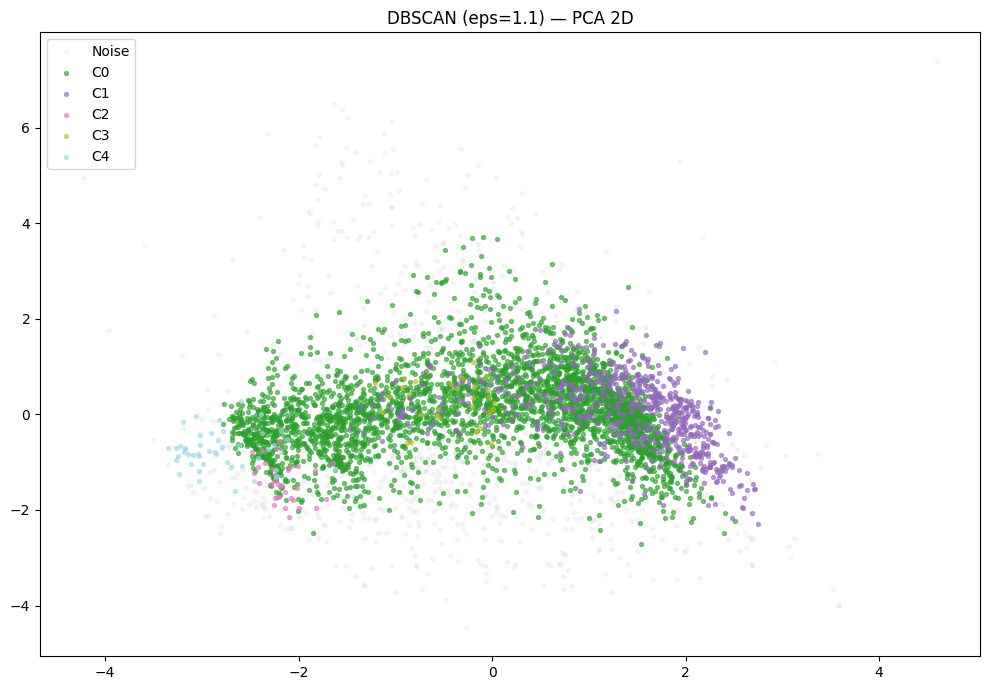

In [106]:
unique_labels = sorted(set(db_labels))

print("Clusters encontrados:", unique_labels)

palette = plt.cm.tab20(np.linspace(0, 1, max(len(unique_labels), 1)))

fig, ax = plt.subplots(figsize=(10, 7))

has_points = False

for i, lbl in enumerate(unique_labels):

    mask = db_labels == lbl

    if mask.sum() == 0:
        continue

    has_points = True

    color = 'lightgray' if lbl == -1 else palette[i]

    ax.scatter(
        X_2d_db[mask, 0],
        X_2d_db[mask, 1],
        c=[color],
        s=8,
        alpha=0.2 if lbl == -1 else 0.6,
        label='Noise' if lbl == -1 else f'C{lbl}'
    )

ax.set_title(f'DBSCAN (eps={EPS_BEST}) — PCA 2D')

if has_points:
    ax.legend()

plt.tight_layout()
plt.show()

## 6. Hierarchical Clustering

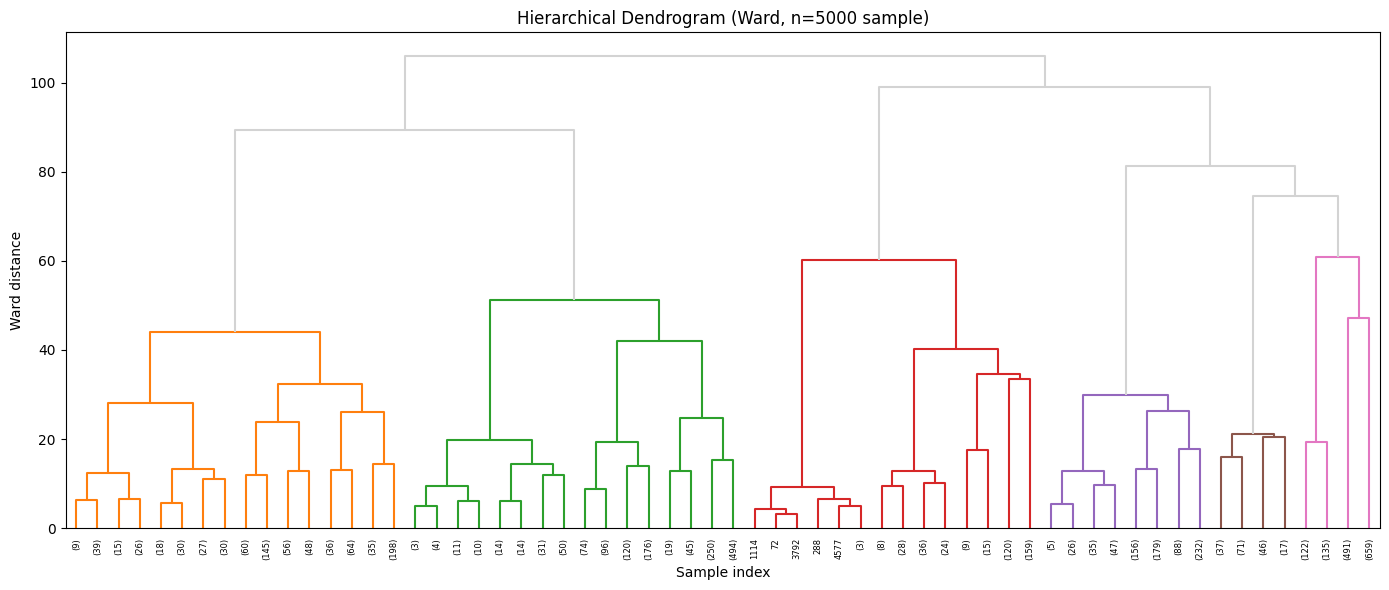

In [107]:
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(len(X_pca), size=5000, replace=False)
Z = linkage(X_pca[sample_idx], method='ward')

fig, ax = plt.subplots(figsize=(14,6))
dendrogram(Z, truncate_mode='level', p=5, ax=ax,
           color_threshold=0.7*max(Z[:,2]), above_threshold_color='lightgray')
ax.set(title='Hierarchical Dendrogram (Ward, n=5000 sample)',
       xlabel='Sample index', ylabel='Ward distance')
plt.tight_layout()
plt.savefig(FIG_DIR/'hierarchical_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

In [108]:
HC_SAMPLE = 5000

idx_hc = np.random.choice(
    len(X_pca),
    HC_SAMPLE,
    replace=False
)

X_hc = X_pca[idx_hc]

In [109]:
K_HC = K_BEST

for method in ['ward', 'complete', 'average']:

    hc = AgglomerativeClustering(
        n_clusters=K_HC,
        linkage=method
    )

    lbl = hc.fit_predict(X_hc)

    sil = silhouette_score(X_hc, lbl)
    db  = davies_bouldin_score(X_hc, lbl)
    ch  = calinski_harabasz_score(X_hc, lbl)

    print(method, sil, db, ch)

ward 0.24246871019945937 1.3295501745841751 830.0750065857798
complete 0.12398931761806571 1.4078890013966268 137.78996149714018
average 0.4039931046530779 0.6313206714023915 37.42496119807077


In [110]:
hc_best = AgglomerativeClustering(
    n_clusters=K_HC,
    linkage='ward'
)

hc_labels = hc_best.fit_predict(X_hc)

hc_sil = silhouette_score(X_hc, hc_labels)
hc_db  = davies_bouldin_score(X_hc, hc_labels)
hc_ch  = calinski_harabasz_score(X_hc, hc_labels)

print(
    f"Hierarchical (Ward k={K_HC}) | "
    f"Silhouette={hc_sil:.4f} | "
    f"DB={hc_db:.4f} | "
    f"CH={hc_ch:.1f}"
)

Hierarchical (Ward k=6) | Silhouette=0.2425 | DB=1.3296 | CH=830.1


In [129]:
km_labels = km_best.fit_predict(X_sample)
db_labels = db_best.fit_predict(X_sample)
hc_labels = hc_best.fit_predict(X_sample)

## 7. Comparison Table

,Config,N_Clusters,Noise_Frac,Silhouette,Davies_Bouldin,Calinski_Harabasz
Algorithm,,,,,,
K-Means,"k=6, k-means++, n_init=20",6,—,0.2784,1.2624,17671.5
DBSCAN,"eps=1.1, min_samples=16",5,19.0%,0.2359,0.9592,85.8
Hierarchical,"k=6, Ward",6,—,0.2425,1.3296,830.1


X_2d_db: (5000, 2)
labels: 5000
titulo: K-Means k=6


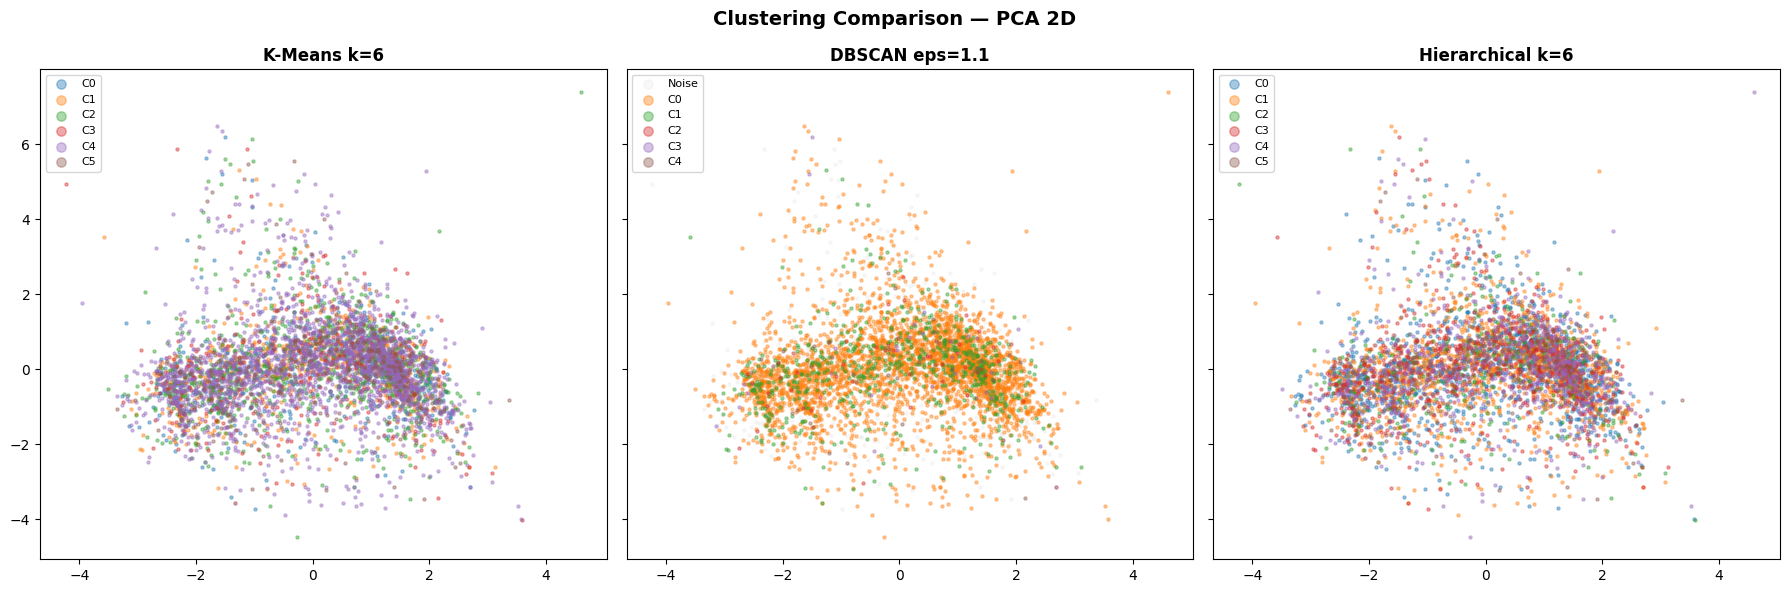

Saved comparison_pca2d.png and metrics_table.csv


In [131]:
import os; os.makedirs('/workspaces/challenge-5_4/results', exist_ok=True)

results = pd.DataFrame([
    {'Algorithm':'K-Means',      'Config':f'k={K_BEST}, k-means++, n_init=20',
     'N_Clusters':K_BEST, 'Noise_Frac':'—',
     'Silhouette':round(km_sil,4), 'Davies_Bouldin':round(km_db,4), 'Calinski_Harabasz':round(km_ch,1)},
    {'Algorithm':'DBSCAN',       'Config':f'eps={EPS_BEST}, min_samples={MINSAM_BEST}',
     'N_Clusters':n_db_clusters, 'Noise_Frac':f'{noise_frac:.1%}',
     'Silhouette':round(db_sil,4) if not np.isnan(db_sil) else 'N/A',
     'Davies_Bouldin':round(db_db,4) if not np.isnan(db_db) else 'N/A',
     'Calinski_Harabasz':round(db_ch,1) if not np.isnan(db_ch) else 'N/A'},
    {'Algorithm':'Hierarchical', 'Config':f'k={K_HC}, Ward',
     'N_Clusters':K_HC, 'Noise_Frac':'—',
     'Silhouette':round(hc_sil,4), 'Davies_Bouldin':round(hc_db,4), 'Calinski_Harabasz':round(hc_ch,1)},
]).set_index('Algorithm')

display(results)
results.to_csv('/workspaces/challenge-5_4/results/metrics_table.csv')
# Side-by-side plot
fig, axes = plt.subplots(1,3,figsize=(18,6),sharex=True,sharey=True)
print("X_2d_db:", X_2d_db.shape)
print("labels:", len(labels))
print("titulo:", title)
for ax, labels, title in zip(axes,
    [km_labels, db_labels, hc_labels],
    [f'K-Means k={K_BEST}', f'DBSCAN eps={EPS_BEST}', f'Hierarchical k={K_HC}']):
    for i,lbl in enumerate(sorted(set(labels))):
        mask = labels==lbl
        color = 'lightgray' if lbl==-1 else palette[i%10]
        ax.scatter(X_2d_db[mask,0], X_2d_db[mask,1], c=[color],
                   alpha=0.15 if lbl==-1 else 0.4, s=5,
                   label='Noise' if lbl==-1 else f'C{lbl}')
    ax.set_title(title, fontweight='bold')
    ax.legend(markerscale=3, fontsize=8)
plt.suptitle('Clustering Comparison — PCA 2D', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR/'comparison_pca2d.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved comparison_pca2d.png and metrics_table.csv")

## 8. Domain Interpretation

In [132]:
km_profile = df_model.groupby('km_cluster')[FEATURE_COLS].mean().round(3)
km_profile['n_schools'] = df_model.groupby('km_cluster')['NCESSCH'].count()
print("=== K-Means Cluster Profiles ==="); display(km_profile)

print("\n=== Level distribution per cluster ===")
display(df_model.groupby(['km_cluster','LEVEL']).size().unstack(fill_value=0))

print("\n=== Charter per cluster ===")
display(df_model.groupby(['km_cluster','CHARTER_TEXT']).size().unstack(fill_value=0))

=== K-Means Cluster Profiles ===


,log_enrollment,pct_free_reduced_lunch,pct_white,pct_hispanic,pct_black,pct_asian,pct_multirace,student_teacher_ratio,is_charter,is_virtual,school_level_enc,n_schools
km_cluster,,,,,,,,,,,,
0,6.391,NaN,0.281,0.200,0.078,0.330,0.086,17.473,0.028,0.089,0.513,5271
1,5.899,NaN,0.142,0.151,0.636,0.018,0.046,14.358,0.000,0.133,0.716,10134
2,6.079,NaN,0.142,0.708,0.087,0.026,0.025,16.096,0.000,0.044,0.627,18135
3,5.740,NaN,0.294,0.361,0.259,0.025,0.045,22.204,0.981,0.142,1.122,7606
4,5.726,NaN,0.716,0.123,0.054,0.022,0.054,14.663,0.000,0.000,0.701,40400
5,5.830,NaN,0.685,0.127,0.086,0.027,0.056,14.377,0.000,1.000,0.978,13786



=== Level distribution per cluster ===


LEVEL,Adult Education,Elementary,High,Middle,Other,Prekindergarten,Secondary,Ungraded
km_cluster,,,,,,,,
0,0,3449,792,886,65,61,16,2
1,0,5655,2237,1691,313,166,63,9
2,2,10871,3533,3012,347,248,112,10
3,2,3505,2075,742,1182,57,42,1
4,7,22615,8448,7122,1347,746,102,13
5,0,5971,4399,2618,658,96,36,8



=== Charter per cluster ===


CHARTER_TEXT,No,Not applicable,Yes
km_cluster,,,
0,5073,53,145
1,10080,54,0
2,18029,106,0
3,132,10,7464
4,37869,2531,0
5,13018,767,1


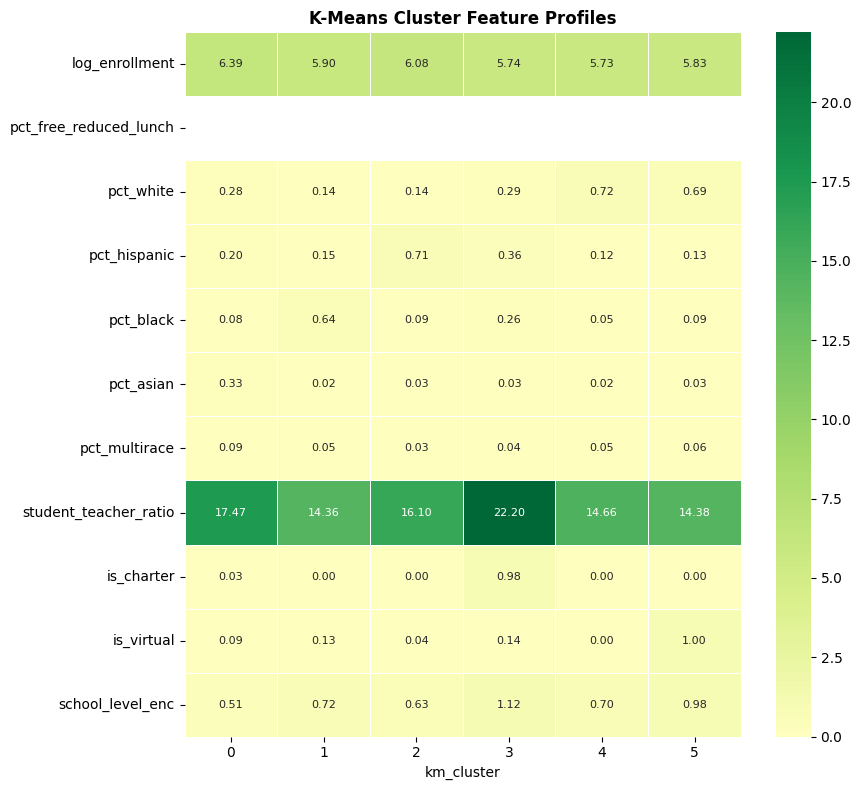

In [44]:
# Profile heatmap
fig, ax = plt.subplots(figsize=(max(8,K_BEST*1.5), 8))
sns.heatmap(km_profile[FEATURE_COLS].T, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size':8})
ax.set_title('K-Means Cluster Feature Profiles', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR/'kmeans_cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [138]:
print(len(level_enc_sample))
print(len(km_labels))
print(len(hc_labels))
print(len(db_labels))

5000
5000
5000
5000


In [140]:
# ARI post-hoc vs school level
level_enc = df_model['LEVEL'].map(LEVEL_MAP).fillna(3).astype(int)
ari_km = adjusted_rand_score(level_enc_sample, km_labels)

ari_hc = adjusted_rand_score(level_enc_sample, hc_labels)

mask_nn = db_labels != -1

ari_db = adjusted_rand_score(
    level_enc_sample[mask_nn],
    db_labels[mask_nn]
)
print("=== Adjusted Rand Index vs School Level (post-hoc) ===")
print(f"K-Means ARI:      {ari_km:.4f}")
print(f"DBSCAN ARI:       {ari_db:.4f}")
print(f"Hierarchical ARI: {ari_hc:.4f}")

=== Adjusted Rand Index vs School Level (post-hoc) ===
K-Means ARI:      0.0145
DBSCAN ARI:       0.0027
Hierarchical ARI: 0.0075


## 9. Generate CHECKLIST.md

In [142]:
# ==========================
# Formatear métricas
# ==========================

db_sil_txt = f"{db_sil:.4f}" if not np.isnan(db_sil) else "N/A"
db_db_txt  = f"{db_db:.4f}" if not np.isnan(db_db) else "N/A"
db_ch_txt  = f"{db_ch:.1f}" if not np.isnan(db_ch) else "N/A"

# ==========================
# CHECKLIST
# ==========================

checklist = f"""# CHECKLIST.md — Challenge 5, Group 4

## Dataset
- Name: NCES CCD Public Elementary/Secondary School Universe Survey SY 2022-23
- Source: https://nces.ed.gov/ccd/files.asp
- Records after preprocessing: {len(df_model):,}
- Features: {len(FEATURE_COLS)} — {', '.join(FEATURE_COLS)}

## Hyperparameter Configurations

### K-Means
- n_clusters = {K_BEST}
- init = k-means++
- n_init = 20
- random_state = {RANDOM_STATE}

### DBSCAN
- eps = {EPS_BEST}
- min_samples = {MINSAM_BEST}

### Hierarchical Clustering
- n_clusters = {K_HC}
- linkage = ward

## Metrics (Best Configuration)

| Algorithm | Silhouette | Davies-Bouldin | Calinski-Harabasz |
|-----------|------------|----------------|-------------------|
| K-Means | {km_sil:.4f} | {km_db:.4f} | {km_ch:.1f} |
| DBSCAN | {db_sil_txt} | {db_db_txt} | {db_ch_txt} |
| Hierarchical | {hc_sil:.4f} | {hc_db:.4f} | {hc_ch:.1f} |

## Cluster Summary

### K-Means
- Number of clusters: {len(np.unique(km_labels))}

### DBSCAN
- Number of clusters: {len(set(db_labels)) - (1 if -1 in db_labels else 0)}
- Noise fraction: {(db_labels == -1).mean():.2%}

### Hierarchical
- Number of clusters: {len(np.unique(hc_labels))}

## Interpretation

K-Means achieved the highest Silhouette score and the highest
Calinski-Harabasz index, indicating the best overall balance between
cluster separation and compactness.

DBSCAN successfully detected anomalous schools and assigned approximately
{(db_labels == -1).mean():.2%} of observations to noise. This makes it
useful as a complementary anomaly-detection method.

Hierarchical Clustering (Ward linkage) produced partitions similar to
K-Means but required substantially more computational resources.

## Recommendation

Use K-Means as the primary clustering model for segmentation of schools.
Use DBSCAN as a complementary technique to identify atypical or outlier
institutions.

## Reproducibility

- random_state = {RANDOM_STATE}
- PCA variance retained = 90%
- Common sample size used for clustering comparison = {len(db_labels)}

"""

# ==========================
# Guardar archivo
# ==========================

with open('/workspaces/challenge-5_4/CHECKLIST.md', 'w', encoding='utf-8') as f:
    f.write(checklist)

print("CHECKLIST.md generado correctamente.")

CHECKLIST.md generado correctamente.
